In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

#### Import the CSV Data as Pandas DataFrame

In [ ]:
df=pd.read_csv("./data/stud.csv")

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

Dataset Information
- gender
- race_ethnicity
- parental_level_of_education
- lunch
- test_preparation_course
- math_score
- reading_score
- writing_score

#### Data Checks to perform

- Check Missing Values
- Check Duplicate Records
- Check datatype
- Check the number of unique values in each column
- Check statistics of dataset
- Check various categories present in categorical columns

In [6]:
## Check Missing Values
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [9]:
df.duplicated().sum()
# If duplicates present -- remove it using drop_duplicates
# df.drop_duplicates(keep="first",inplace=True)

0

In [10]:
# Check Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [11]:
# Checking number of unique values of each column

df.nunique(axis=0)

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [12]:
# Check statistics of dataset

df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Insight :

- From above description of numerical data, all means are very close to each other - between 68-69
- All Standard Deviation is also close
- While there is minimum score 0 for math, writing minimum is much higher = 10 and reading minimum score is 17.

- Further we can see the mean and median are very close to each other for each subject, which means there are no outliers in this dataset

In [14]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [16]:
# Exploring Data
for column in df.columns[:5]:
    print(f"Unique Categories in {column} :")
    print(df[column].unique())
    print()

Unique Categories in gender :
['female' 'male']

Unique Categories in race_ethnicity :
['group B' 'group C' 'group A' 'group D' 'group E']

Unique Categories in parental_level_of_education :
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

Unique Categories in lunch :
['standard' 'free/reduced']

Unique Categories in test_preparation_course :
['none' 'completed']



In [20]:
# Check numerical features / Categorical features
# Check discrete features / continous features

numerical_features=[feature for feature in df.columns if df[feature].dtype!="object"]
print("Numerical Feature :",numerical_features)
categorical_features=[feature for feature in df.columns if feature not in numerical_features]
print("Categorical Feature :",categorical_features)

Numerical Feature : ['math_score', 'reading_score', 'writing_score']
Categorical Feature : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [21]:
df["gender"].unique()

array(['female', 'male'], dtype=object)

In [22]:
discrete_feature=[feature for feature in df.columns if len(df[feature].unique())<25]
print("Discrete Features :",discrete_feature)

continous_feature=[feature for feature in df.columns if len(df[feature].unique())>=25]
print("Continous Features :",continous_feature)

Discrete Features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
Continous Features : ['math_score', 'reading_score', 'writing_score']


In [23]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [24]:
# Adding Columns for Total Score and Average
df["total_score"]=df["math_score"]+df["reading_score"]+df["writing_score"]
df["average"]=df["total_score"]/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [29]:
reading_full=df[df["reading_score"]==100]["gender"].count()
print("Number of Students with full marks in reading :",reading_full)
math_full=df[df["math_score"]==100]["gender"].count()
print("Number of Students with full marks in math :",math_full)
writing_full=df[df["writing_score"]==100]["gender"].count()
print("Number of Students with full marks in writing :",writing_full)

Number of Students with full marks in reading : 17
Number of Students with full marks in math : 7
Number of Students with full marks in writing : 14


In [31]:
reading_less_20=df[df["reading_score"]<=20]["gender"].count()
print("Number of Students with marks less than 20 in reading :",reading_less_20)
math_less_20=df[df["math_score"]<=20]["gender"].count()
print("Number of Students with full marks less than 20 in math :",math_less_20)
writing_less_20=df[df["writing_score"]<=20]["gender"].count()
print("Number of Students with full marks less than 20 in writing :",writing_less_20)

Number of Students with marks less than 20 in reading : 1
Number of Students with full marks less than 20 in math : 4
Number of Students with full marks less than 20 in writing : 3


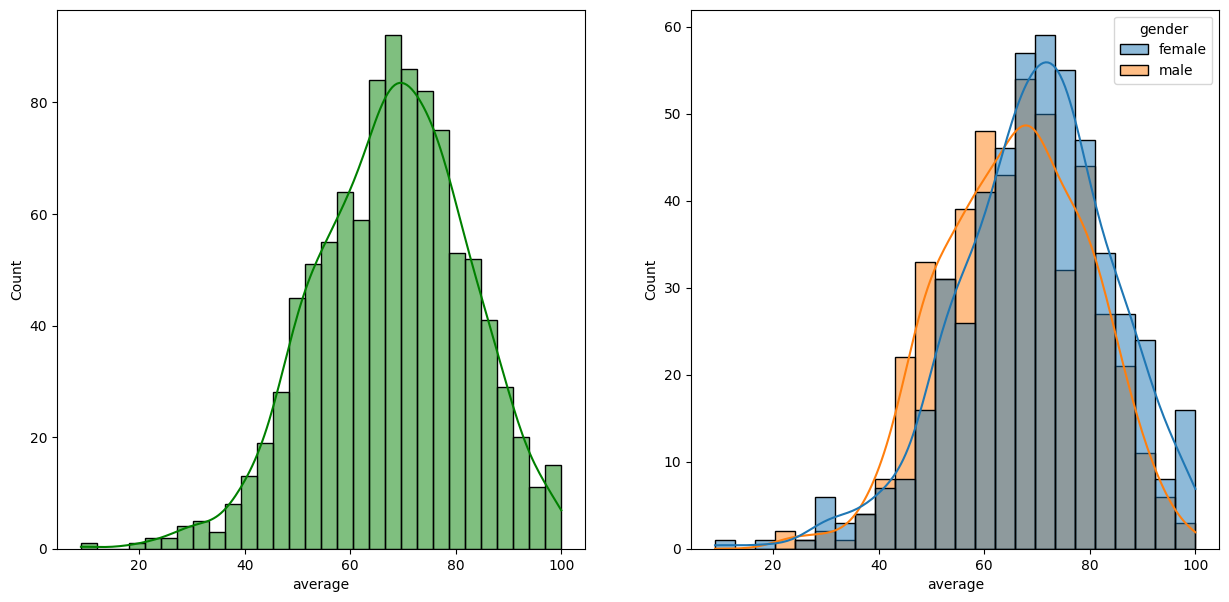

In [36]:
# Histogram and KDE

fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x="average",bins=30,kde=True,color="g")
plt.subplot(122)
sns.histplot(data=df,x="average",kde=True,hue="gender")
plt.show()

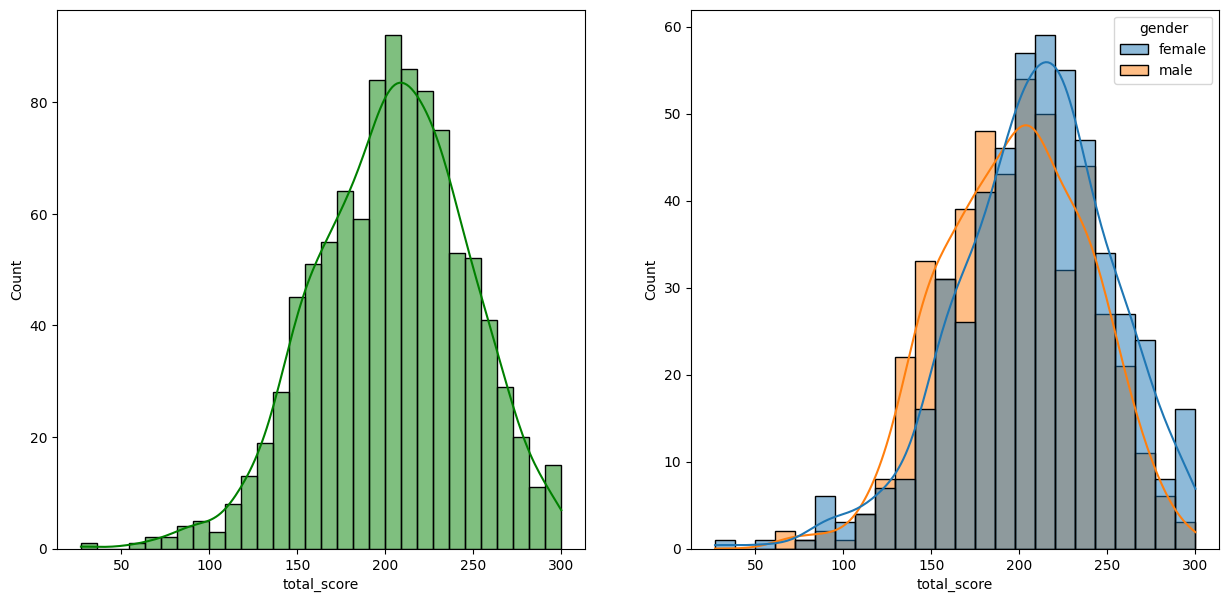

In [37]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x="total_score",bins=30,kde=True,color="g")
plt.subplot(122)
sns.histplot(data=df,x="total_score",kde=True,hue="gender")
plt.show()

Insights
- Female students tend to perform well than male students

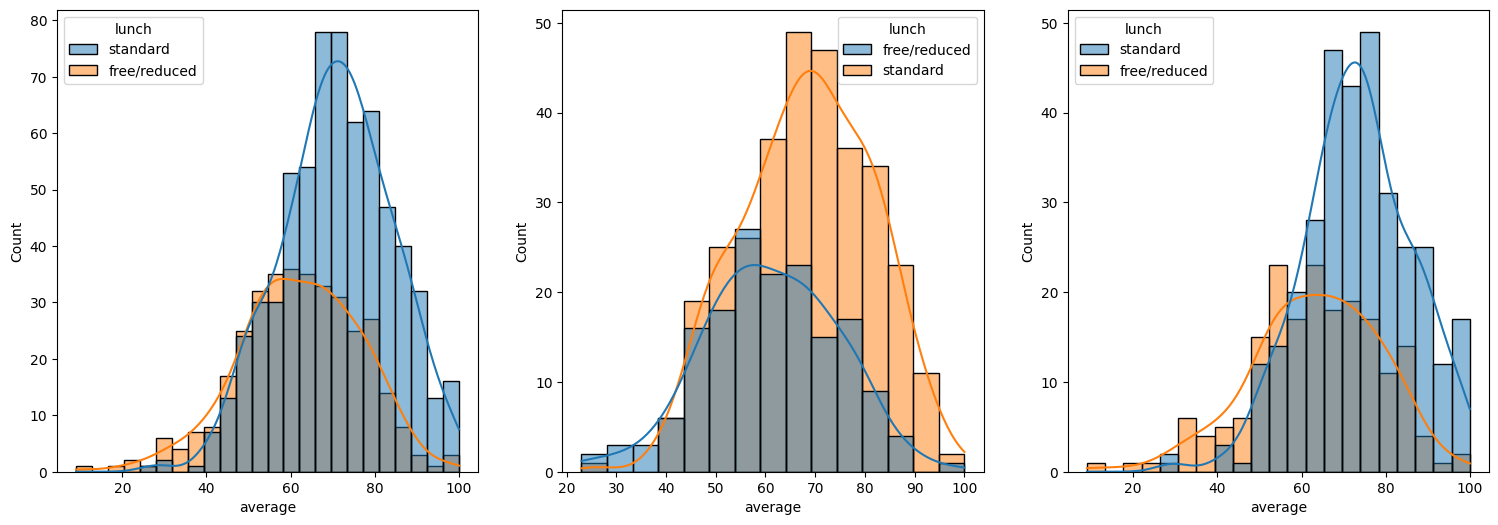

In [41]:
# Check Female and Male Scores with lunch
fig, axs = plt.subplots(1,2,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x="average",kde=True,hue="lunch")
plt.subplot(142)
sns.histplot(data=df[df["gender"]=="male"],x="average",kde=True,hue="lunch")
plt.subplot(143)
sns.histplot(data=df[df["gender"]=="female"],x="average",kde=True,hue="lunch")
plt.show()

Standard Lunch helps to perform well in exams , be it male or female

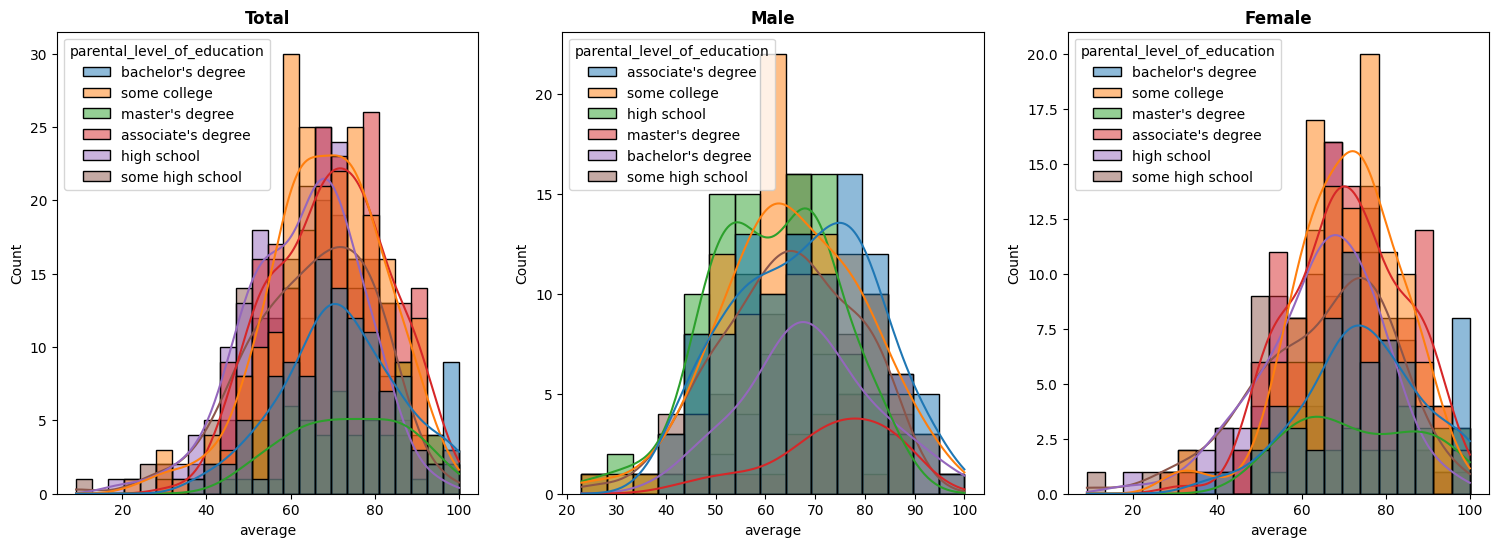

In [42]:
# Check Female and Male Scores with parental_level_of_education
fig, axs = plt.subplots(1,2,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x="average",kde=True,hue="parental_level_of_education")
plt.title("Total",weight="bold")
plt.subplot(142)
sns.histplot(data=df[df["gender"]=="male"],x="average",kde=True,hue="parental_level_of_education")
plt.title("Male",weight="bold")
plt.subplot(143)
sns.histplot(data=df[df["gender"]=="female"],x="average",kde=True,hue="parental_level_of_education")
plt.title("Female",weight="bold")
plt.show()

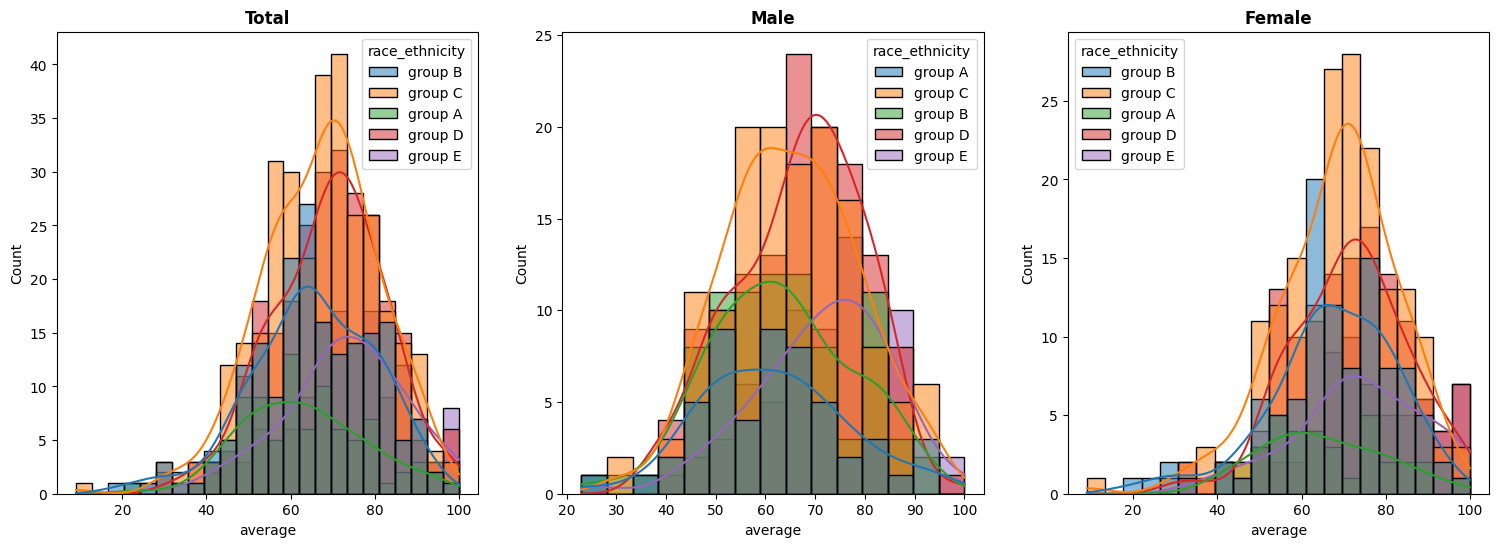

In [43]:
# Check Female and Male Scores with race_ethnicity
fig, axs = plt.subplots(1,2,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x="average",kde=True,hue="race_ethnicity")
plt.title("Total",weight="bold")
plt.subplot(142)
sns.histplot(data=df[df["gender"]=="male"],x="average",kde=True,hue="race_ethnicity")
plt.title("Male",weight="bold")
plt.subplot(143)
sns.histplot(data=df[df["gender"]=="female"],x="average",kde=True,hue="race_ethnicity")
plt.title("Female",weight="bold")
plt.show()

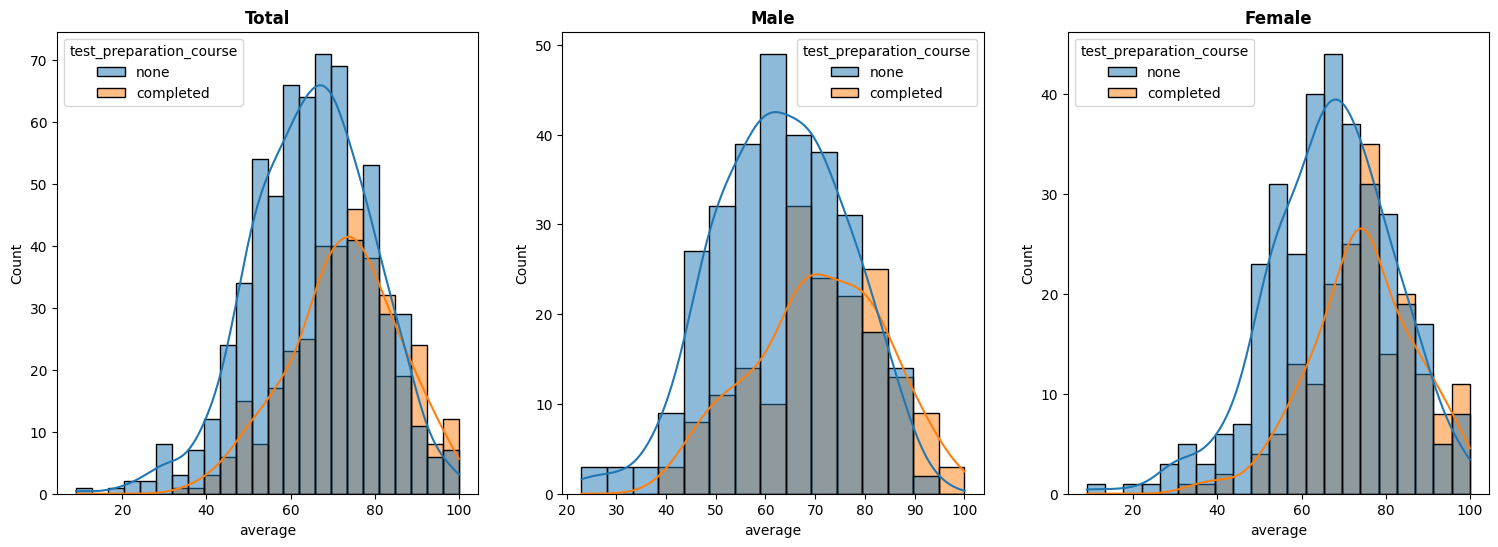

In [44]:
# Check Female and Male Scores with test_preparation_course
fig, axs = plt.subplots(1,2,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x="average",kde=True,hue="test_preparation_course")
plt.title("Total",weight="bold")
plt.subplot(142)
sns.histplot(data=df[df["gender"]=="male"],x="average",kde=True,hue="test_preparation_course")
plt.title("Male",weight="bold")
plt.subplot(143)
sns.histplot(data=df[df["gender"]=="female"],x="average",kde=True,hue="test_preparation_course")
plt.title("Female",weight="bold")
plt.show()

Insights :
- parental education does not affect much -- but we do see associate and some college -- have higher data
- group c and d are well performing groups
- from test preparation course those who didnt enroll to test course have performed well